In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv
import os
load_dotenv("../configuration/.env")

import sqlalchemy as db

from sklearn.cluster import KMeans
from ydata_profiling import ProfileReport

# Loading information from data warehouse

## Data Warehouse Connection

In [9]:
# connect to MySQL database data warehouse
username =os.getenv('MYSQL_USER')
password = (':' + os.getenv('MYSQL_PASSWORD')) if os.getenv('MYSQL_PASSWORD') != None else ''
host = os.getenv('MYSQL_HOST')
port = os.getenv('MYSQL_PORT')
database = os.getenv('MYSQL_DATABASE_DW')

uriMysql = f"mysql://{username}{password}@{host}/{database}"
print(uriMysql)
client= db.create_engine(uriMysql)

mysql://root:@localhost/dw_netflix


## get data

In [168]:
from sqlalchemy import BigInteger

query = """
SELECT factwatchs.userID,
       dimmovie.title, dimmovie.releaseDate, dimmovie.genre, dimmovie.award as movieAward,
       dimscore.netflixScore, dimscore.imdbScore, dimscore.rottentomatoesScore, dimscore.sensacineScore, dimscore.peopleScore,
       dimperformer.name as performerName, dimperformer.role performerRole, dimperformer.award as performerAward,
       diminteraction.finishCount, diminteraction.backClickCount, diminteraction.movieForwardCount, diminteraction.playCount, diminteraction.movieViewPercentage
FROM factwatchs
INNER JOIN dimmovie ON factwatchs.movieID = dimmovie.movieID
INNER JOIN dimuser ON factwatchs.userID = dimuser.userID
INNER JOIN dimscore ON factwatchs.scoreID = dimscore.scoreID
LEFT JOIN dimperformer ON factwatchs.performerID = dimperformer.performerID
INNER JOIN diminteraction ON factwatchs.interactionID = diminteraction.interactionID
"""

fact_watchs_df = pd.read_sql(query,client)
fact_watchs_df["releaseDate"] = pd.to_datetime(fact_watchs_df["releaseDate"])

print(fact_watchs_df.columns)
print(fact_watchs_df.info())

Index(['userID', 'title', 'releaseDate', 'genre', 'movieAward', 'netflixScore',
       'imdbScore', 'rottentomatoesScore', 'sensacineScore', 'peopleScore',
       'performerName', 'performerRole', 'performerAward', 'finishCount',
       'backClickCount', 'movieForwardCount', 'playCount',
       'movieViewPercentage'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9662 entries, 0 to 9661
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   userID               9662 non-null   int64         
 1   title                9662 non-null   object        
 2   releaseDate          9662 non-null   datetime64[ns]
 3   genre                9662 non-null   object        
 4   movieAward           9662 non-null   object        
 5   netflixScore         7911 non-null   float64       
 6   imdbScore            7891 non-null   float64       
 7   rottentomatoesScore  7860 non-nul

In [169]:
movies_df =pd.read_sql_table('dimmovie',client)
scores_df =pd.read_sql_table('dimscore',client)
users_df =pd.read_sql_table('dimuser',client)
performer_df =pd.read_sql_table('dimperformer',client)

print(movies_df.columns)
print(movies_df.info())
print("\n")
print(users_df.columns)
print(users_df.info())
print("\n")
print(scores_df.columns)
print(scores_df.info())
print("\n")
print(performer_df.columns)
print(performer_df.info())

Index(['movieID', 'title', 'releaseDate', 'genre', 'award'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9155 entries, 0 to 9154
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   movieID      9155 non-null   object        
 1   title        9155 non-null   object        
 2   releaseDate  9154 non-null   datetime64[ns]
 3   genre        9155 non-null   object        
 4   award        9125 non-null   object        
dtypes: datetime64[ns](1), object(4)
memory usage: 357.7+ KB
None


Index(['userID', 'username', 'country'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9125 entries, 0 to 9124
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userID    9125 non-null   int64 
 1   username  9125 non-null   object
 2   country   0 non-null      object
dtypes: int64(1), object(2)
memory usage: 214.0+ KB
N

## analize

### analize all variables and find relationships

In [170]:
# profile = ProfileReport(fact_watchs_df, title="movie_data Profiling Report")
# profile.to_widgets()

### filter and work with most representative variables

In [171]:
query = """
SELECT factwatchs.userID,
       dimmovie.title, dimmovie.genre, dimmovie.award as movieAward,
       dimscore.netflixScore, dimscore.imdbScore, dimscore.rottentomatoesScore, dimscore.sensacineScore,
       dimperformer.name as performerName
FROM factwatchs
INNER JOIN dimmovie ON factwatchs.movieID = dimmovie.movieID
INNER JOIN dimuser ON factwatchs.userID = dimuser.userID
INNER JOIN dimscore ON factwatchs.scoreID = dimscore.scoreID
LEFT JOIN dimperformer ON factwatchs.performerID = dimperformer.performerID
"""

fact_watchs_df = pd.read_sql(query,client)
fact_watchs_df

,userID,title,genre,movieAward,netflixScore,imdbScore,rottentomatoesScore,sensacineScore,performerName
0,0,"Billy Blazes, Esq.",Comedy,Oscar,5.0,2.0,5.0,3.0,Leonardo DiCaprio
1,1,"Cabinet of Dr. Caligari, The (Cabinet des Dr. ...",Crime,Sin Info,NaN,3.0,3.0,2.0,Johnny Depp
2,2,"Mark of Zorro, The",Adventure,Sin Info,3.0,5.0,2.0,5.0,Christopher Nolan
3,2,"Mark of Zorro, The",Adventure,Grammy,3.0,5.0,2.0,5.0,None
4,3,"Goat, The",Comedy,Oscar,5.0,3.0,1.0,1.0,Clint Eastwood
...,...,...,...,...,...,...,...,...,...
9657,9120,Piper,Animation,Oscar,5.0,4.0,4.0,NaN,None
9658,9121,Hell or High Water,Crime,Grammy,1.0,2.0,2.0,5.0,None
9659,9122,Family Band: The Cowsills Story,Documentary,Sin Info,NaN,5.0,4.0,2.0,None
9660,9123,The Lovers and the Despot,Comedy,Grammy,5.0,2.0,3.0,1.0,None


### filling missing values

In [172]:
# filling missing score values
fact_watchs_df[["netflixScore","imdbScore","rottentomatoesScore","sensacineScore"]] = fact_watchs_df[["netflixScore","imdbScore","rottentomatoesScore","sensacineScore"]].fillna(0)

#filling missing award values
fact_watchs_df["movieAward"] = fact_watchs_df["movieAward"].fillna("Sin Info")

#filling missing performers values
fact_watchs_df["performerName"] = fact_watchs_df["performerName"].fillna("No Info")


### calculating mean and median global score

In [173]:
# calculating mean score
fact_watchs_df["score"] = fact_watchs_df[["netflixScore","imdbScore","rottentomatoesScore","sensacineScore"]].mean(axis=1)

             score
count  9662.000000
mean      2.524555
std       0.931928
min       0.000000
25%       1.750000
50%       2.500000
75%       3.250000
max       5.000000
median: 2.5


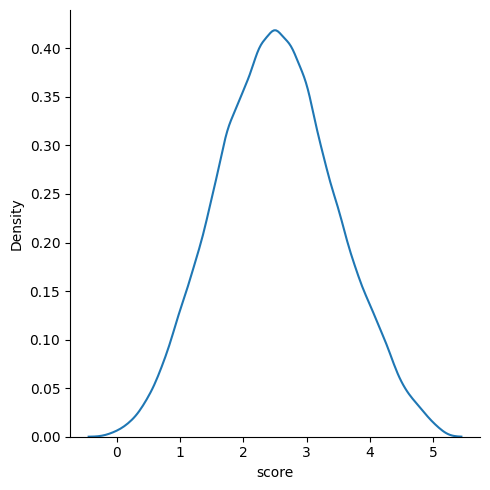

In [174]:
# draw some graphs distributions
scores_df = fact_watchs_df[["title","score"]]

sns.displot(scores_df, x="score", kind="kde")

print(scores_df.describe())
print(f"median: {scores_df["score"].median()}")

### keep only the movies that were scored above the mean

In [175]:
above_mean_condition = fact_watchs_df['score'] > fact_watchs_df['score'].mean()
fact_watchs_df = fact_watchs_df[above_mean_condition]

### use a pivot table to see which genre is the best for each user depending on the score

In [176]:
tabla_model = pd.pivot_table(fact_watchs_df, values='score', index=['userID'],
                       columns=['genre'], aggfunc="mean").reset_index()

tabla_model = tabla_model.fillna(0)

tabla_model.head(10)

genre,userID,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0.00,0.00,0.0,0.0,3.75,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.00,3.75,0.0,0.0,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,0.00,0.00,0.0,0.0,3.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5,0.00,0.00,0.0,0.0,3.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,6,0.00,0.00,0.0,0.0,0.00,2.75,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,8,0.00,3.00,0.0,0.0,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,9,0.00,0.00,0.0,0.0,0.00,0.00,0.0,2.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,10,0.00,0.00,0.0,0.0,3.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,11,0.00,0.00,0.0,0.0,0.00,0.00,0.0,2.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,12,3.25,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## K-Means Clustering

In [177]:
X1 = tabla_model[['Action', 'Adventure', 'Animation', 'Children', 'Comedy',
       'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
       'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War',
       'Western']].iloc[: , :].values

inertia = []
for n in range(1 , 11):
    algorithm = (KMeans(n_clusters = n ,init='k-means++', n_init = 20 ,max_iter=300,
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )
    algorithm.fit(X1)
    inertia.append(algorithm.inertia_)

c:\Users\joa_g\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1418: RuntimeWarning: algorithm='elkan' doesn't make sense for a single cluster. Using 'lloyd' instead.
  warnings.warn(


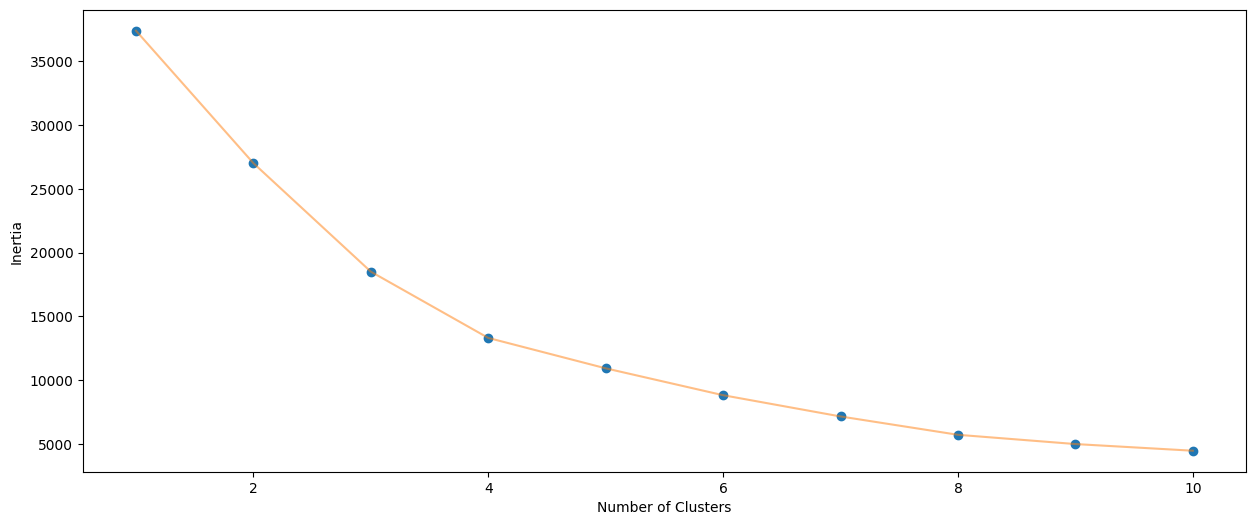

In [178]:
plt.figure(1 , figsize = (15 ,6))
plt.plot(np.arange(1 , 11) , inertia , 'o')
plt.plot(np.arange(1 , 11) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

### select number of clusters to group movies by genre

In [179]:
kmeans_1 = KMeans(n_clusters=7, random_state=0)

#  use fit_predict to cluster the dataset
predictions = kmeans_1.fit_predict(tabla_model[['Action', 'Adventure', 'Animation', 'Children', 'Comedy',
       'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
       'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War',
       'Western']].fillna(0))

tabla_model['Cluster'] = predictions

### now we can classify each user to its favorite genre

In [180]:
movies_datacluster = fact_watchs_df.merge(tabla_model[['userID','Cluster']],on='userID',how='left')
movies_datacluster.head()

,userID,title,genre,movieAward,netflixScore,imdbScore,rottentomatoesScore,sensacineScore,performerName,score,Cluster
0,0,"Billy Blazes, Esq.",Comedy,Oscar,5.0,2.0,5.0,3.0,Leonardo DiCaprio,3.75,0
1,2,"Mark of Zorro, The",Adventure,Sin Info,3.0,5.0,2.0,5.0,Christopher Nolan,3.75,4
2,2,"Mark of Zorro, The",Adventure,Grammy,3.0,5.0,2.0,5.0,No Info,3.75,4
3,4,"Boat, The",Comedy,Grammy,4.0,0.0,4.0,4.0,Leonardo DiCaprio,3.00,0
4,5,"Play House, The",Comedy,Oscar,1.0,2.0,4.0,5.0,Leonardo DiCaprio,3.00,0


we can check to which cluster does the user #61 belong

In [181]:
user_61_filter = movies_datacluster["userID"]==61

print(f"user 61 belongs to cluster {movies_datacluster[user_61_filter]["Cluster"].head(1).values}")

user 61 belongs to cluster [1]


Top movies from cluster 1

In [182]:
#cluster 1 genre
cluster_filter = movies_datacluster["Cluster"]==1
print(f"cluster 1 genre {movies_datacluster[cluster_filter]["genre"].head(1).values}")

ranking_cluster1 = movies_datacluster[cluster_filter].groupby(['title'])["score"].mean().sort_values(ascending=False)
ranking_cluster1 = ranking_cluster1.reset_index()
ranking_cluster1

cluster 1 genre ['Drama']


,title,score
0,"Man from Snowy River, The",5.00
1,"Star Is Born, A",5.00
2,"Phantom of the Opera, The",5.00
3,Woman in the Dunes (Suna no onna),5.00
4,Savage Messiah,5.00
...,...,...
948,"Goodbye, Mr. Chips",2.75
949,"Good Mother, The",2.75
950,Gone with the Wind,2.75
951,Godzilla (Gojira),2.75


what movies did the user #61 watch?

In [183]:
# user #61 watched
movies_watched = movies_datacluster[user_61_filter]["title"]
print(f"user 61 watched \n {movies_watched}")

print("\n")

# user #61 did not watch
movies_not_watched = ranking_cluster1[~ranking_cluster1["title"].isin(movies_watched)]
movies_not_watched.sort_values("score",ascending=False)[0:10]
print(f"user #61 did not watch \n {movies_not_watched}")

user 61 watched 
 44    Napoléon 
Name: title, dtype: object


user #61 did not watch 
                                   title  score
0            Man from Snowy River, The    5.00
1                      Star Is Born, A    5.00
2            Phantom of the Opera, The    5.00
3    Woman in the Dunes (Suna no onna)    5.00
4                       Savage Messiah    5.00
..                                  ...    ...
948                 Goodbye, Mr. Chips    2.75
949                   Good Mother, The    2.75
950                 Gone with the Wind    2.75
951                  Godzilla (Gojira)    2.75
952                    'Round Midnight    2.75

[952 rows x 2 columns]


putting the movies as columns

In [184]:
user_movie_ratings=pd.pivot_table(fact_watchs_df, values='score', index=['userID'],
                       columns=['title'], aggfunc="mean")

user_movie_ratings

title,"""Great Performances"" Cats",'Hellboy': The Seeds of Creation,'Neath the Arizona Skies,'Round Midnight,'Til There Was You,...And Justice for All,1-900 (06),10 Years,"10,000 BC",101 Dalmatians,...,Zero Dark Thirty,Zero Effect,Zerophilia,Zombeavers,Zombieland,Zootopia,"Zorro, the Gay Blade",Zulu,xXx,xXx: State of the Union
userID,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


we will generate clusters based on the movies the users have seen and scored

In [185]:
from scipy.sparse import csr_matrix

for column in user_movie_ratings.columns:
    user_movie_ratings[column] = pd.arrays.SparseArray(user_movie_ratings[column], dtype=pd.SparseDtype("float", 0))

user_movie_ratings = user_movie_ratings.fillna(0)

user_movie_ratings.head()

title,"""Great Performances"" Cats",'Hellboy': The Seeds of Creation,'Neath the Arizona Skies,'Round Midnight,'Til There Was You,...And Justice for All,1-900 (06),10 Years,"10,000 BC",101 Dalmatians,...,Zero Dark Thirty,Zero Effect,Zerophilia,Zombeavers,Zombieland,Zootopia,"Zorro, the Gay Blade",Zulu,xXx,xXx: State of the Union
userID,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [186]:
sparse_ratings = csr_matrix(user_movie_ratings.sparse.to_coo())

In [187]:
predictions = KMeans(n_clusters=20, algorithm='lloyd').fit_predict(sparse_ratings)

In [200]:
clustered = pd.concat([user_movie_ratings.reset_index(), pd.DataFrame({'group':predictions})], axis=1)

movies_datacluster_peliculas = fact_watchs_df.merge(clustered[['userID','group']],on='userID',how='left')

movies_datacluster_peliculas

,userID,title,genre,movieAward,netflixScore,imdbScore,rottentomatoesScore,sensacineScore,performerName,score,group
0,0,"Billy Blazes, Esq.",Comedy,Oscar,5.0,2.0,5.0,3.0,Leonardo DiCaprio,3.75,0
1,2,"Mark of Zorro, The",Adventure,Sin Info,3.0,5.0,2.0,5.0,Christopher Nolan,3.75,0
2,2,"Mark of Zorro, The",Adventure,Grammy,3.0,5.0,2.0,5.0,No Info,3.75,0
3,4,"Boat, The",Comedy,Grammy,4.0,0.0,4.0,4.0,Leonardo DiCaprio,3.00,0
4,5,"Play House, The",Comedy,Oscar,1.0,2.0,4.0,5.0,Leonardo DiCaprio,3.00,0
...,...,...,...,...,...,...,...,...,...,...,...
4353,9117,Popstar: Never Stop Never Stopping,Comedy,Grammy,4.0,3.0,5.0,1.0,No Info,3.25,0
4354,9120,Piper,Animation,Oscar,5.0,4.0,4.0,0.0,No Info,3.25,0
4355,9122,Family Band: The Cowsills Story,Documentary,Sin Info,0.0,5.0,4.0,2.0,No Info,2.75,0
4356,9123,The Lovers and the Despot,Comedy,Grammy,5.0,2.0,3.0,1.0,No Info,2.75,0


let's check user #61 again what movies has he watched

In [198]:
user_61_filter = movies_datacluster_peliculas["userID"]==61
user_61_cluster = movies_datacluster_peliculas[user_61_filter]["group"].head(1).values[0]
movies_datacluster_peliculas[user_61_filter][["group","genre"]]


,group,genre
44,0,Drama


movies on users cluster

In [196]:
top_peliculas = clustered[clustered["group"]==user_61_cluster][clustered.columns[1: len(clustered.columns) -1]].mean().reset_index()
top_peliculas.rename(columns={0:"ranking"},inplace=True)
top_peliculas

,index,ranking
0,"""Great Performances"" Cats",0.000712
1,'Hellboy': The Seeds of Creation,0.000971
2,'Neath the Arizona Skies,0.000777
3,'Round Midnight,0.000712
4,'Til There Was You,0.000842
...,...,...
3688,Zootopia,0.000777
3689,"Zorro, the Gay Blade",0.000842
3690,Zulu,0.001813
3691,xXx,0.000712


what movies can we recommend to user #61

In [ ]:
top_peliculas[ ~top_peliculas["title"].isin(movies_datacluster_peliculas[movies_datacluster_peliculas ["userID"]==61]["title"])].sort_values("ranking",ascending=False)[0:10]

,title,ranking
1422,Hamlet,0.007376
1727,Jane Eyre,0.004658
3332,"Three Musketeers, The",0.0044
609,Carrie,0.0044
2546,"Phantom of the Opera, The",0.003882
670,Cinderella,0.003494
1222,Freaky Friday,0.003494
2540,Peter Pan,0.0033
1824,King Solomon's Mines,0.0033
3396,"Trip, The",0.003106
